# CPU Scheduling Algorithm Benchmark

Compares RR, MMMRR, ADRR, EED-RR, ElvHLVQRR on 10 dataset partitions
(1,000 processes each; total 10,000 processes).

**Data:** `process_data.csv` — columns: `Process`, `Burst time`, `Arrival Time`

**Metrics:** AWT (Avg Waiting Time), ATT (Avg Turnaround Time), CS (Context Switches)




In [1]:
import sys
sys.path.append('Code')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import wilcoxon
from scheduler_runners import ALGORITHM_REGISTRY

In [2]:
# ─────────────────────── Configuration ───────────────────────
CSV_PATH = "process_data.csv"
BLOCK_SIZE = 1000
NUM_DATASETS = 10
METRICS = ["AWT", "ATT", "CS"]

# Plot style
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.family"] = "DejaVu Sans"

ALGO_COLORS = {
    "RR":        "#7f8c8d",   # gray – baseline
    "MMMRR":     "#e74c3c",   # red
    "ADRR":      "#f39c12",   # orange
    "ElvHLVQRR": "#2ecc71",   # green
    "EED-RR":    "#3498db",   # blue – our algorithm
}

METRIC_LABELS = {
    "AWT": "Avg Waiting Time (AWT)",
    "ATT": "Avg Turnaround Time (ATT)",
    "CS":  "Context Switches (CS)",
}

## 1. Load Data

In [3]:
print("=" * 60)
print("CPU Scheduling Algorithm Benchmark")
print("=" * 60)

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH} — {len(df):,} rows\n")

CPU Scheduling Algorithm Benchmark
Loaded: process_data.csv — 10,000 rows



## 2. Build 10 Datasets

In [4]:
datasets = []
for block in range(NUM_DATASETS):
    start = block * BLOCK_SIZE
    end = start + BLOCK_SIZE
    block_df = df.iloc[start:end]
    processes = []
    for _, row in block_df.iterrows():
        name = str(row["Process"])
        arrival = float(row["Arrival Time"])
        burst = float(row["Burst time"])
        burst = max(1, burst)  # ensure positive burst
        processes.append([name, arrival, burst])
    datasets.append(processes)
    print(f"  Dataset {block + 1}: {len(processes):,} processes (rows {start}–{end - 1})")

print(f"\nTotal: {len(datasets)} datasets ready\n")

  Dataset 1: 1,000 processes (rows 0–999)
  Dataset 2: 1,000 processes (rows 1000–1999)
  Dataset 3: 1,000 processes (rows 2000–2999)
  Dataset 4: 1,000 processes (rows 3000–3999)
  Dataset 5: 1,000 processes (rows 4000–4999)
  Dataset 6: 1,000 processes (rows 5000–5999)
  Dataset 7: 1,000 processes (rows 6000–6999)
  Dataset 8: 1,000 processes (rows 7000–7999)
  Dataset 9: 1,000 processes (rows 8000–8999)
  Dataset 10: 1,000 processes (rows 9000–9999)

Total: 10 datasets ready



### 2.1. Dataset Characteristics

Table 2 shows the main properties of the ten groups, where each group contains 1,000 process data points. 
The average burst time is similar across all groups (around 200–221 time units). However, there is different 
variation in burst time. Groups P1 to P5 have higher variation (approximately 110–121 time units) and 
groups P6 to P10 have lower variation (approximately 52–57 time units). This indicates that the first five 
groups contain more mixed workloads and the last five groups contain more balanced workloads. Arrival 
times are also mostly similar across all groups, with average values around 48–54 time units.

In [5]:
print('=' * 88)
print('Table 2. Distributional features of the ten benchmark partitions.')
print('=' * 88)
header = f"{str('Partition'):<10} | {str('Mean Burst (tu)'):<15} | {str('Std Burst (tu)'):<15} | {str('Processes'):<10} | {str('Mean Arrival (tu)'):<18} | {str('Std Arrival (tu)'):<16}"
print(header)
print('-' * len(header))

for i, processes in enumerate(datasets):
    bursts = [p[2] for p in processes]
    arrivals = [p[1] for p in processes]
    mean_burst = np.mean(bursts)
    std_burst = np.std(bursts, ddof=1)
    mean_arrival = np.mean(arrivals)
    std_arrival = np.std(arrivals, ddof=1)
    
    row = f"P{i+1:<9} | {mean_burst:>15.2f} | {std_burst:>15.2f} | {len(processes):>10,} | {mean_arrival:>18.2f} | {std_arrival:>16.2f}"
    print(row)
print('-' * len(header))


Table 2. Distributional features of the ten benchmark partitions.
Partition  | Mean Burst (tu) | Std Burst (tu)  | Processes  | Mean Arrival (tu)  | Std Arrival (tu)
---------------------------------------------------------------------------------------------------
P1         |          203.80 |           51.43 |      1,000 |              51.39 |            16.16
P2         |          205.86 |           55.28 |      1,000 |              51.87 |            16.54
P3         |          208.77 |           54.22 |      1,000 |              51.38 |            16.21
P4         |          207.05 |           53.44 |      1,000 |              51.95 |            16.56
P5         |          206.43 |           53.20 |      1,000 |              51.57 |            16.24
P6         |          207.17 |           51.98 |      1,000 |              52.38 |            16.34
P7         |          207.49 |           52.39 |      1,000 |              52.85 |            16.02
P8         |          204.54 |    

## 3. Run Benchmark

In [6]:
algo_names = list(ALGORITHM_REGISTRY.keys())
results = {algo: {m: [] for m in METRICS} for algo in algo_names}

for part_idx, processes in enumerate(datasets):
    print(f"Partition {part_idx + 1}/{NUM_DATASETS}...", end=" ")
    for algo_name, runner in ALGORITHM_REGISTRY.items():
        try:
            res = runner(processes)
            for m in METRICS:
                results[algo_name][m].append(res[m])
        except Exception as e:
            print(f"  {algo_name} failed: {e}")
    print("done")

print("\nBenchmark complete.\n")

Partition 1/10... done
Partition 2/10... done
Partition 3/10... done
Partition 4/10... done
Partition 5/10... done
Partition 6/10... done
Partition 7/10... done
Partition 8/10... done
Partition 9/10... done
Partition 10/10... done

Benchmark complete.



## 4. Results Per Partition (Tables)


In [7]:
metrics_to_print = [("AWT", "Average waiting time"), ("ATT", "Average turnaround time"), ("CS", "Context switches")]

for m_key, m_desc in metrics_to_print:
    print("=" * 75)
    print(f"Table. {m_desc} per partition for all algorithms")
    print("=" * 75)
    
    header = f"{'Partition':<10}"
    for algo in algo_names:
        header += f" {algo:>11}"
    print(header)
    print("-" * len(header))
    
    for i in range(NUM_DATASETS):
        row = f"P{i+1:<9}"
        for algo in algo_names:
            val = results[algo][m_key][i]
            if m_key == "CS":
                row += f" {val:>11.0f}"
            else:
                row += f" {val:>11.2f}"
        print(row)
    print("\n")


Table. Average waiting time per partition for all algorithms
Partition        MMMRR        ADRR      EED-RR   ElvHLVQRR          RR
----------------------------------------------------------------------
P1           142997.81   131949.52   114014.02   117950.02   144036.30
P2           143709.45   132305.12   116430.78   129694.63   143818.27
P3           145018.93   133582.11   115786.67   118894.61   145923.53
P4           143856.02   133722.60   114741.31   121919.79   143862.33
P5           142813.33   130115.36   112876.49   126194.29   143981.07
P6           146316.96   133635.99   116496.42   127089.20   146339.15
P7           144022.93   133377.86   113715.37   126472.15   144082.71
P8           140164.59   129924.76   114607.03   126367.18   140933.00
P9           143862.12   131777.14   115210.69   131215.43   143922.28
P10          141100.51   129484.11   111031.84   113051.00   141751.18


Table. Average turnaround time per partition for all algorithms
Partition        MMMR

## 5. Summary Table

In [8]:
print("=" * 75)
print("SUMMARY — Mean ± Standard Deviation across all partitions")
print("=" * 75)

summary_mean = {}
summary_std = {}
for algo in algo_names:
    summary_mean[algo] = {m: np.mean(results[algo][m]) for m in METRICS}
    summary_std[algo] = {m: np.std(results[algo][m], ddof=1) for m in METRICS}

# Print table header
header = f"{'Algorithm':<14}"
for m in METRICS:
    header += f"  {m:>20}"
print(header)
print("-" * len(header))

for algo in algo_names:
    row = f"{algo:<14}"
    for m in METRICS:
        mean_val = summary_mean[algo][m]
        std_val = summary_std[algo][m]
        if m == "CS":
            s = f"{mean_val:.0f} ± {std_val:.0f}"
            row += f"  {s:>20}"
        else:
            s = f"{mean_val:.2f} ± {std_val:.2f}"
            row += f"  {s:>20}"
    print(row)

print()
summary = summary_mean


SUMMARY — Mean ± Standard Deviation across all partitions
Algorithm                        AWT                   ATT                    CS
--------------------------------------------------------------------------------
MMMRR            143386.26 ± 1773.09   143592.49 ± 1774.13              1496 ± 3
ADRR             131987.46 ± 1645.78   132193.68 ± 1646.77              1341 ± 7
EED-RR           114491.06 ± 1681.89   114697.29 ± 1682.41              1076 ± 8
ElvHLVQRR        123884.83 ± 5747.53   124091.05 ± 5747.73            1762 ± 295
RR               143864.98 ± 1616.56   144071.21 ± 1617.57              1501 ± 3



## 6. Statistical Significance & Effect Size

In [9]:
def cohend(d1, d2):
    n1, n2 = len(d1), len(d2)
    s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
    if s1 == 0 and s2 == 0:
        return 0.0
    s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = np.mean(d1), np.mean(d2)
    return (u1 - u2) / s

print("=" * 80)
print("Statistical Significance (Wilcoxon Signed-Rank Test) & Effect Size")
print("EED-RR vs. Baselines (n=10 partitions)")
print("=" * 80)

header = f"{'Metric':<6} | {'Baseline':<12} | {'p-value':<10} | {'Significance':<15} | {'Cohens_d':<10}"
print(header)
print("-" * len(header))

for m in METRICS:
    eed_data = results["EED-RR"][m]
    for algo in algo_names:
        if algo == "EED-RR":
            continue
        baseline_data = results[algo][m]
        
        # Wilcoxon test
        try:
            w_stat, p_val = wilcoxon(eed_data, baseline_data)
        except ValueError:
            p_val = 1.0
            
        # Cohen's d (Effect size)
        d_val = cohend(eed_data, baseline_data)
        
        sig = "p < 0.05 (*)" if p_val < 0.05 else "Not Sig"
        if p_val < 0.01:
            sig = "p < 0.01 (**)"
        if p_val < 0.001:
            sig = "p < 0.001 (***)"
            
        print(f"{m:<6} | {algo:<12} | {p_val:<10.2e} | {sig:<15} | {d_val:<10.2f}")
    print("-" * len(header))
print("\n")


Statistical Significance (Wilcoxon Signed-Rank Test) & Effect Size
EED-RR vs. Baselines (n=10 partitions)
Metric | Baseline     | p-value    | Significance    | Cohens_d  
-----------------------------------------------------------------
AWT    | MMMRR        | 1.95e-03   | p < 0.01 (**)   | -16.72    
AWT    | ADRR         | 1.95e-03   | p < 0.01 (**)   | -10.52    
AWT    | ElvHLVQRR    | 1.95e-03   | p < 0.01 (**)   | -2.22     
AWT    | RR           | 1.95e-03   | p < 0.01 (**)   | -17.81    
-----------------------------------------------------------------
ATT    | MMMRR        | 1.95e-03   | p < 0.01 (**)   | -16.71    
ATT    | ADRR         | 1.95e-03   | p < 0.01 (**)   | -10.51    
ATT    | ElvHLVQRR    | 1.95e-03   | p < 0.01 (**)   | -2.22     
ATT    | RR           | 1.95e-03   | p < 0.01 (**)   | -17.80    
-----------------------------------------------------------------
CS     | MMMRR        | 1.95e-03   | p < 0.01 (**)   | -66.15    
CS     | ADRR         | 1.95e-03   |

## 7. Improvement of EED-RR

In [10]:
print("=" * 60)
print("EED-RR Improvement over other algorithms (%)")
print("=" * 60)

eed_rr_vals = summary["EED-RR"]
header = f"{'vs Algorithm':<14}"
for m in METRICS:
    header += f"  {m:>12}"
print(header)
print("-" * len(header))

for algo in algo_names:
    if algo == "EED-RR":
        continue
    row = f"{algo:<14}"
    for m in METRICS:
        other = summary[algo][m]
        ours = eed_rr_vals[m]
        if other != 0:
            improvement = ((other - ours) / other) * 100
        else:
            improvement = 0
        row += f"  {improvement:>11.2f}%"
    print(row)

print()

EED-RR Improvement over other algorithms (%)
vs Algorithm             AWT           ATT            CS
--------------------------------------------------------
MMMRR                 20.15%        20.12%        28.11%
ADRR                  13.26%        13.24%        19.81%
ElvHLVQRR              7.58%         7.57%        38.94%
RR                    20.42%        20.39%        28.33%



## 8. Plots

### 8a. Grouped bar chart: Mean metrics

Saved: benchmark_bar_comparison_AWT.png


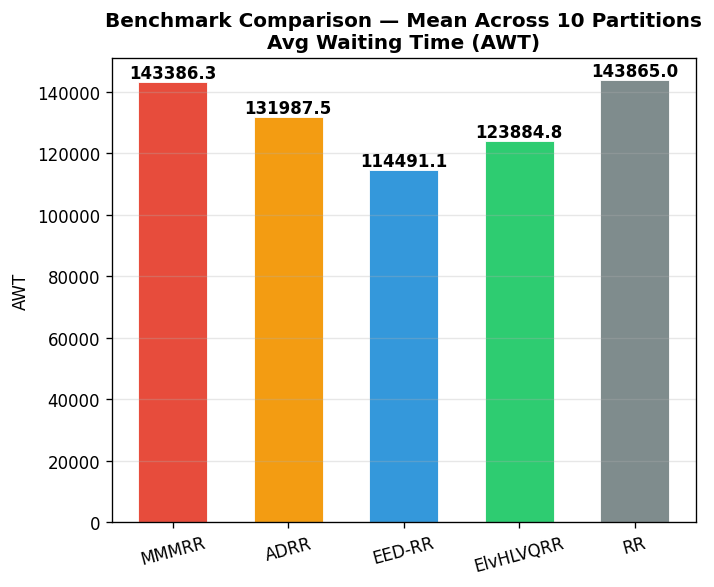

Saved: benchmark_bar_comparison_ATT.png


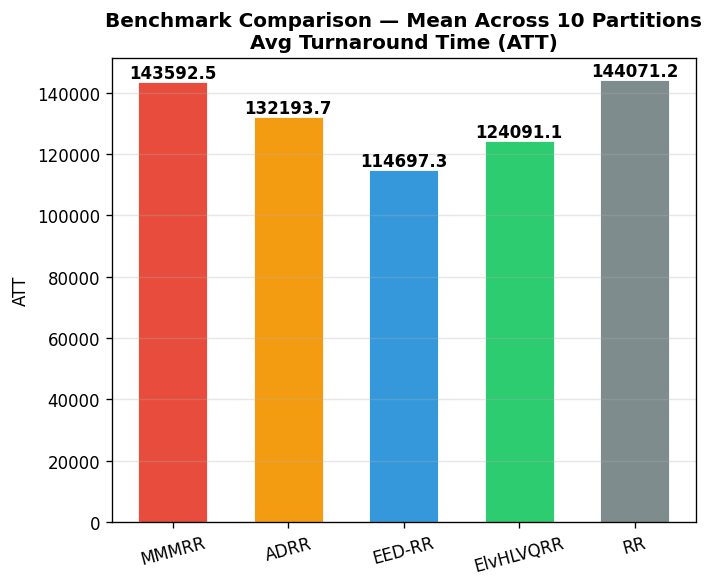

Saved: benchmark_bar_comparison_CS.png


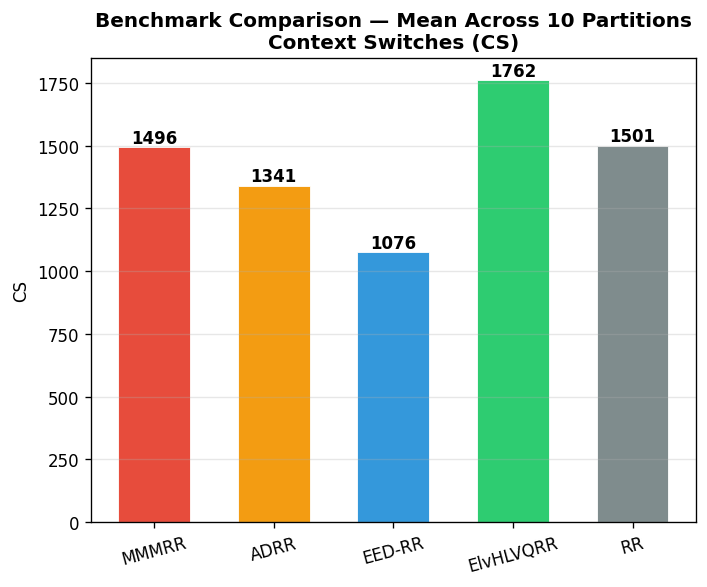

In [11]:
x = np.arange(len(algo_names))
width = 0.6

for m in METRICS:
    fig, ax = plt.subplots(figsize=(6,5))
    vals = [summary[algo][m] for algo in algo_names]
    colors = [ALGO_COLORS.get(algo, "#95a5a6") for algo in algo_names]
    bars = ax.bar(x, vals, width, color=colors, edgecolor="white", linewidth=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, vals):
        label = f"{val:.0f}" if m == "CS" else f"{val:.1f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                label, ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_title(f"Benchmark Comparison — Mean Across 10 Partitions\n{METRIC_LABELS[m]}", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(algo_names, fontsize=10, rotation=15)
    ax.set_ylabel(m)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"Image/benchmark_bar_comparison_{m}.png", dpi=150, bbox_inches="tight")
    print(f"Saved: benchmark_bar_comparison_{m}.png")
    plt.show()


### 8b. Per-partition line plots

Saved: benchmark_partition_comparison_AWT.png


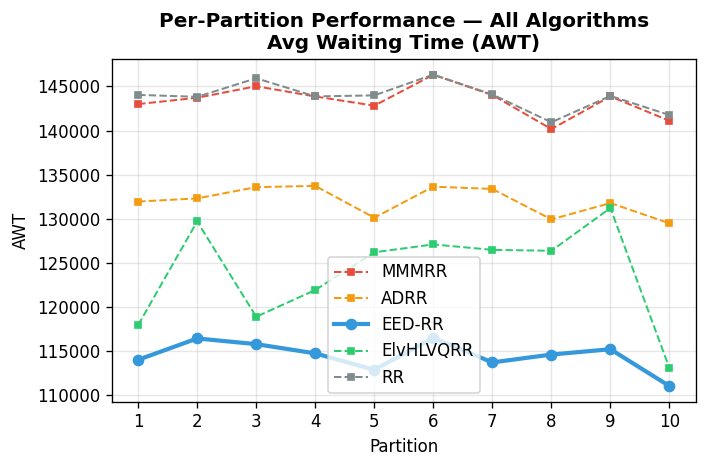

Saved: benchmark_partition_comparison_ATT.png


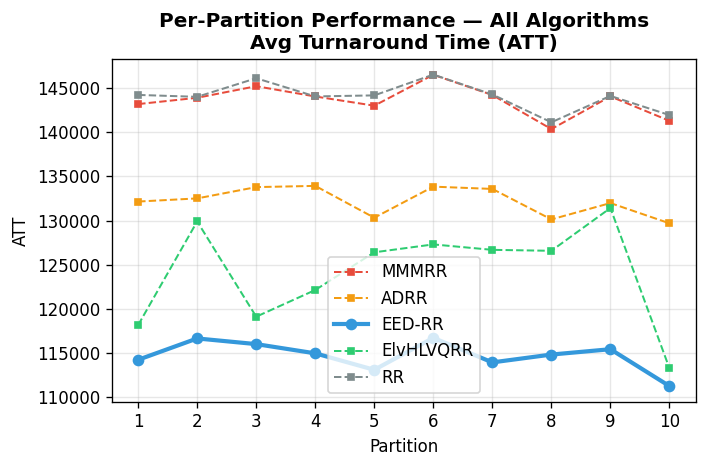

Saved: benchmark_partition_comparison_CS.png


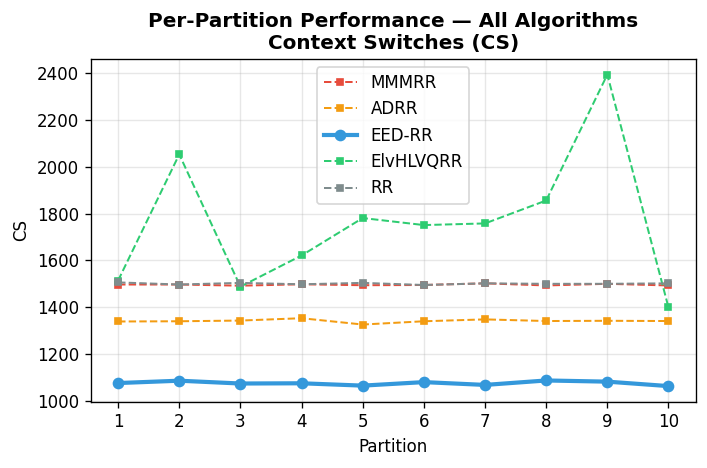

In [12]:
partitions = list(range(1, NUM_DATASETS + 1))

for m in METRICS:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    for algo in algo_names:
        style = "-o" if algo == "EED-RR" else "--s"
        lw = 2.5 if algo == "EED-RR" else 1.2
        ms = 6 if algo == "EED-RR" else 4
        ax.plot(partitions, results[algo][m],
                style, label=algo,
                color=ALGO_COLORS.get(algo, "#95a5a6"),
                linewidth=lw, markersize=ms)

    ax.set_title(f"Per-Partition Performance — All Algorithms\n{METRIC_LABELS[m]}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Partition")
    ax.set_ylabel(m)
    ax.set_xticks(partitions)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"Image/benchmark_partition_comparison_{m}.png", dpi=150, bbox_inches="tight")
    print(f"Saved: benchmark_partition_comparison_{m}.png")
    plt.show()


### 8c. Improvement heatmap

Saved: benchmark_improvement_heatmap.png


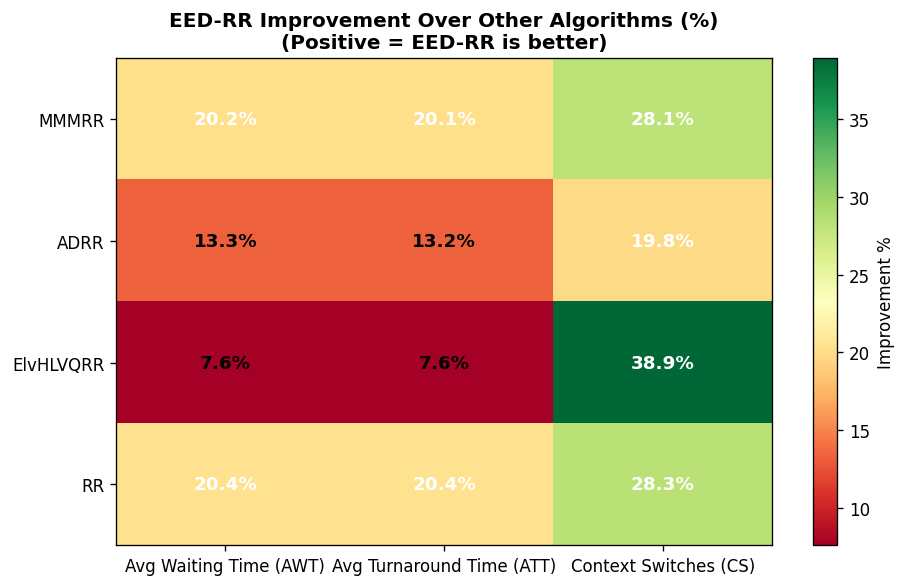


All benchmarks complete!


In [13]:
improvement_data = []
compare_algos = [a for a in algo_names if a != "EED-RR"]

for algo in compare_algos:
    row = []
    for m in METRICS:
        other = summary[algo][m]
        ours = eed_rr_vals[m]
        if other != 0:
            improvement = ((other - ours) / other) * 100
        else:
            improvement = 0
        row.append(improvement)
    improvement_data.append(row)

imp_df = pd.DataFrame(improvement_data, index=compare_algos, columns=METRICS)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(imp_df.values, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_yticks(range(len(compare_algos)))
ax.set_yticklabels(compare_algos, fontsize=10)

# Add text annotations
for i in range(len(compare_algos)):
    for j in range(len(METRICS)):
        val = imp_df.values[i, j]
        color = "white" if abs(val) > 15 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

ax.set_title("EED-RR Improvement Over Other Algorithms (%)\n(Positive = EED-RR is better)",
             fontsize=12, fontweight="bold")
plt.colorbar(im, label="Improvement %")
plt.tight_layout()
plt.savefig("Image/benchmark_improvement_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: benchmark_improvement_heatmap.png")
plt.show()

print("\n" + "=" * 60)
print("All benchmarks complete!")
print("=" * 60)

### 9. EED-RR Scaling Factor Analysis
We run `EED-RR` across the scaling factors [1.0, 1.5, 2.0, 2.5, 3.0 , 3.5, 4.0, 4.5, 5.0 , 5.5, 6.0 , 6.5, 7.0] to observe how adjusting the algorithm's elasticity impacts Wait Time, Turnaround Time, and Context Switches.

Evaluating EED-RR Scaling Factor Impact (1.0 to 7.0)
Processing Partition 10/10 for scaling factors...
Evaluation complete.



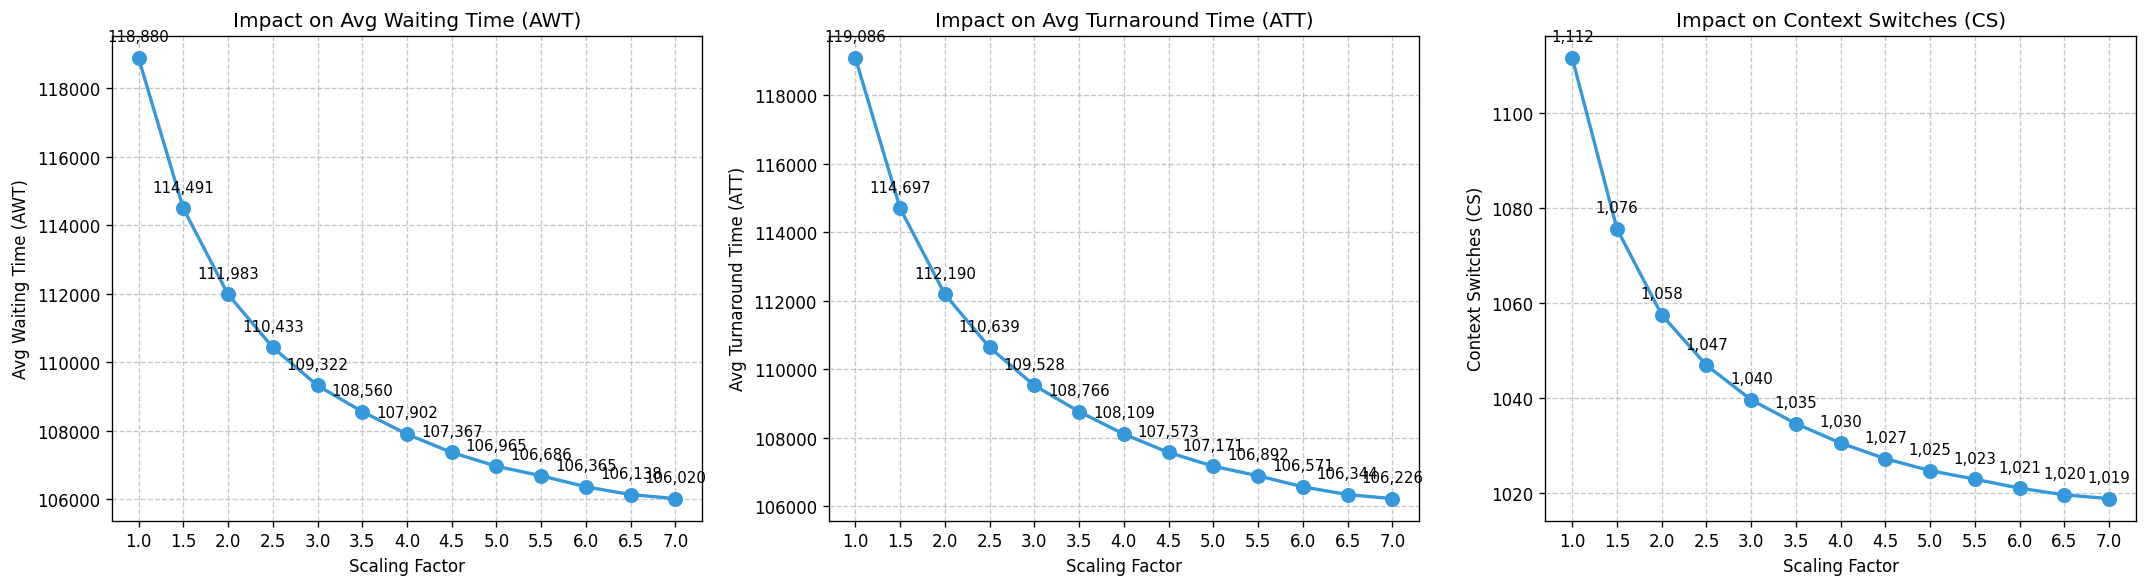

Scaling Factor  | AWT        | ATT        | CS        
-------------------------------------------------------
1.0             | 118880.09  | 119086.32  | 1112      
1.5             | 114491.06  | 114697.29  | 1076      
2.0             | 111983.37  | 112189.60  | 1058      
2.5             | 110432.56  | 110638.78  | 1047      
3.0             | 109322.20  | 109528.42  | 1040      
3.5             | 108559.57  | 108765.79  | 1035      
4.0             | 107902.43  | 108108.66  | 1030      
4.5             | 107367.00  | 107573.23  | 1027      
5.0             | 106964.79  | 107171.02  | 1025      
5.5             | 106686.19  | 106892.41  | 1023      
6.0             | 106364.66  | 106570.89  | 1021      
6.5             | 106137.61  | 106343.83  | 1020      
7.0             | 106019.57  | 106225.80  | 1019      


In [14]:
# ─────────────────── EED-RR Scaling Factor Impact ────────────────────────
print("=" * 60)
print("Evaluating EED-RR Scaling Factor Impact (1.0 to 7.0)")
print("=" * 60)

scaling_factors = [1.0, 1.5, 2.0, 2.5, 3.0 , 3.5, 4.0, 4.5, 5.0 , 5.5, 6.0 , 6.5, 7.0]
sf_results = {sf: {m: [] for m in METRICS} for sf in scaling_factors}

from scheduler_runners import run_EED_RR

for i, processes in enumerate(datasets):
    print(f"Processing Partition {i+1}/{NUM_DATASETS} for scaling factors...", end="\r")
    for sf in scaling_factors:
        res = run_EED_RR(processes, scaling_factor=sf)
        for m in METRICS:
            sf_results[sf][m].append(res[m])
print("\nEvaluation complete.\n")

# Calculate means
sf_means = {sf: {m: np.mean(sf_results[sf][m]) for m in METRICS} for sf in scaling_factors}

# Plot
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))
for idx, m in enumerate(METRICS):
    ax = axes[idx]
    y_vals = [sf_means[sf][m] for sf in scaling_factors]
    ax.plot(scaling_factors, y_vals, marker='o', linestyle='-', color='#3498db', linewidth=2, markersize=8)
    ax.set_title(f"Impact on {METRIC_LABELS[m]}")
    ax.set_xlabel("Scaling Factor")
    ax.set_ylabel(METRIC_LABELS[m])
    ax.set_xticks(scaling_factors)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Annotate points
    for sf, y in zip(scaling_factors, y_vals):
        ax.annotate(f"{y:,.0f}", (sf, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Image/benchmark_scaling_factor_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Print Table
print(f"{'Scaling Factor':<15} | {'AWT':<10} | {'ATT':<10} | {'CS':<10}")
print("-" * 55)
for sf in scaling_factors:
    print(f"{sf:<15.1f} | {sf_means[sf]['AWT']:<10.2f} | {sf_means[sf]['ATT']:<10.2f} | {sf_means[sf]['CS']:<10.0f}")


### 10. Ablation Study

In [15]:
from EED_RR_Ablation import run_EED_RR

ablation_modes = {
    'Base (No Fairness)': 0,
    'Base + JFI': 1,
    'Base + JFI + Deficit': 2,
    'Full EED-RR': 3
}

ablation_results = {name: {"AWT": [], "ATT": [], "CS": []} for name in ablation_modes.keys()}

for part_idx, processes in enumerate(datasets):
    for mode_name, mode_id in ablation_modes.items():
        result = run_EED_RR(processes, ablation_mode=mode_id)
        ablation_results[mode_name]["AWT"].append(result["AWT"])
        ablation_results[mode_name]["ATT"].append(result["ATT"])
        ablation_results[mode_name]["CS"].append(result["CS"])

# Print formatted table
print(f"{'Configuration':<30} | {'AWT':<9} | {'ATT':<9} | {'CS':<6}")
print("-" * 60)

for mode_name in ablation_modes.keys():
    awt_mean = sum(ablation_results[mode_name]["AWT"]) / len(datasets)
    att_mean = sum(ablation_results[mode_name]["ATT"]) / len(datasets)
    cs_mean = sum(ablation_results[mode_name]["CS"]) / len(datasets)
    
    print(f"{mode_name:<30} | {awt_mean:<9.2f} | {att_mean:<9.2f} | {cs_mean:>6.0f}")


Configuration                  | AWT       | ATT       | CS    
------------------------------------------------------------
Base (No Fairness)             | 143864.98 | 144071.21 |   1501
Base + JFI                     | 118880.09 | 119086.32 |   1112
Base + JFI + Deficit           | 118880.09 | 119086.32 |   1112
Full EED-RR                    | 114491.06 | 114697.29 |   1076
